# 02 — Treinamento do ensemble stacking

Usa exclusivamente o treino exportado pelo 01_preproc_eda. Entrada: Titulo + Noticia + Autor; 0 = Fake, 1 = Real. Bases: regressão logística, random forest e SVC linear (LinearSVC). O estimador final é uma regressão logística.

Cada base ajusta seu próprio TF-IDF dentro das dobras do stacking. O estimador final recebe escores fora da amostra, sem as features originais (passthrough=False). Uma validação cruzada externa ao stacking produz as previsões usadas no diagnóstico interno. O holdout e a base externa ficam reservados ao 03; não são carregados aqui.

Os parâmetros são fixados antes da execução. Não há busca de hiperparâmetros nem declaração antecipada de superioridade. Reutilizar as métricas internas para ajustes transforma este resultado em evidência de desenvolvimento. A auditoria automática identifica sinais e duplicatas exatas; não certifica independência por evento, fonte ou paráfrase.

Experimento exploratório com a base original, sem exigir revisão manual integral. Essa condição é registrada no manifesto; não há certificação de ausência de contaminação editorial.

Quando as partições do 01 estão ausentes, a primeira célula executa o pré-processamento automaticamente. Artefatos existentes incompatíveis ou alterados interrompem a execução; não há fallback para bases antigas.

Cada algoritmo possui sua própria seção e célula de treinamento. A comparação final usa as mesmas cinco dobras e as mesmas features.


In [1]:
from pathlib import Path
import sys
import json
import platform
import warnings
from time import perf_counter
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import Markdown, display
from typing import cast
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_recall_fscore_support,
                             roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score)
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v2_validacao_externa"
    if (module_dir / "pipeline_utils.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
import importlib
import pipeline_utils
importlib.reload(pipeline_utils)
pipeline_utils.ensure_preprocessed_data(pipeline_utils.project_root())
# O 01 pode recarregar o módulo: importe os objetos atualizados após sua execução.
importlib.reload(pipeline_utils)
from pipeline_utils import (project_root, compose_text, normalize_text, validate_labels,
                            sha256_file, load_bundle, LABEL_NAMES, SCHEMA_VERSION, MODEL_RELATIVE,
                            INPUT_POLICY, FEATURE_COLUMNS, checking_signals,
                            TRAIN_COLUMNS, PROCESSED_COLUMNS, EXTERNAL_COLUMNS,
                            validate_schema, InputSchemaValidator, make_features, prepare_authors,
                            load_manifest, read_partition, fitted_base_features)
ROOT = project_root()
DATA_DIR = ROOT / "notebooks/v2_validacao_externa/data/processed/texto_autor_exploratorio_v4"
REPORT_DIR = ROOT / "reports/v2_stacking_texto_autor_exploratorio"
GRAPH_DIR = REPORT_DIR / "graficos"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
N_SPLITS = 5


## 1. Contrato de entrada e auditoria do treino

A execução interrompe se o manifesto, os rótulos ou o esquema forem incompatíveis. Não exige ficha de revisão e não remove palavras automaticamente.

Features obrigatórias: `Titulo`, `Noticia`, `Autor`. Rótulo original: `Classe`; nas partições do 01: `label`. Os nomes são exatos e não são inferidos por posição. Uma coluna ausente gera ValueError antes da transformação ou do ajuste. A coluna Autor deve existir, mesmo quando a autoria é desconhecida e seu valor está vazio.


In [2]:
manifest = load_manifest(DATA_DIR)
if sha256_file(DATA_DIR / "train.csv") != manifest["files"]["train.csv"]:
    raise ValueError("Treino alterado após o notebook 01.")
if sha256_file(ROOT / "data/FakeRecogna.xlsx") != manifest["raw_sha256"]:
    raise ValueError("Base original alterada. Execute novamente o notebook 01.")
train = read_partition(DATA_DIR / "train.csv")
validate_schema(train, PROCESSED_COLUMNS, context="treino do 01")
if train.id_original.isna().any() or train.id_original.duplicated().any():
    raise ValueError("IDs ausentes ou duplicados no treino.")
if train.texto.isna().any():
    raise ValueError("Texto ausente no treino.")
normalized = train.texto.map(normalize_text)
if normalized.eq("").any() or normalized.duplicated().any():
    raise ValueError("Texto vazio ou duplicata normalizada. Revise no notebook 01.")
if not compose_text(train).map(normalize_text).eq(normalized).all():
    raise ValueError("Texto composto diverge das colunas do 01.")
if train["Noticia"].astype(str).str.strip().eq("").any():
    raise ValueError("Noticia vazia no treino. Revise a entrada no notebook 01.")
X_train = train.loc[:, FEATURE_COLUMNS].copy().reset_index(drop=True)
print("Features de entrada:", X_train.columns.tolist())
y_train = validate_labels(train.label).reset_index(drop=True)
# A dobra externa precisa comportar também as cinco dobras internas.
if set(y_train) != {0, 1} or y_train.value_counts().min() < 10:
    raise ValueError("São necessárias ambas as classes e pelo menos 10 registros por classe.")
auditoria = train[["id_original", "label"]].copy()
auditoria["autor_normalizado"] = prepare_authors(train).ravel()
auditoria["palavras"] = normalized.map(lambda text: len(str(text).split()))
auditoria["pistas_residuais"] = train.texto.map(lambda text: " | ".join(checking_signals(text)))
auditoria.to_csv(REPORT_DIR / "auditoria_treino.csv", index=False)
display(auditoria.groupby("label").agg(n=("id_original", "size"),
    mediana_palavras=("palavras", "median"),
    textos_sinalizados=("pistas_residuais", lambda s: s.ne("").sum())))
print("Sinais residuais exigem contexto; não equivalem a contaminação confirmada.")


Features de entrada: ['Titulo', 'Noticia', 'Autor']


,n,mediana_palavras,textos_sinalizados
label,,,
0,4752,75.0,3409
1,4766,104.0,115


Sinais residuais exigem contexto; não equivalem a contaminação confirmada.


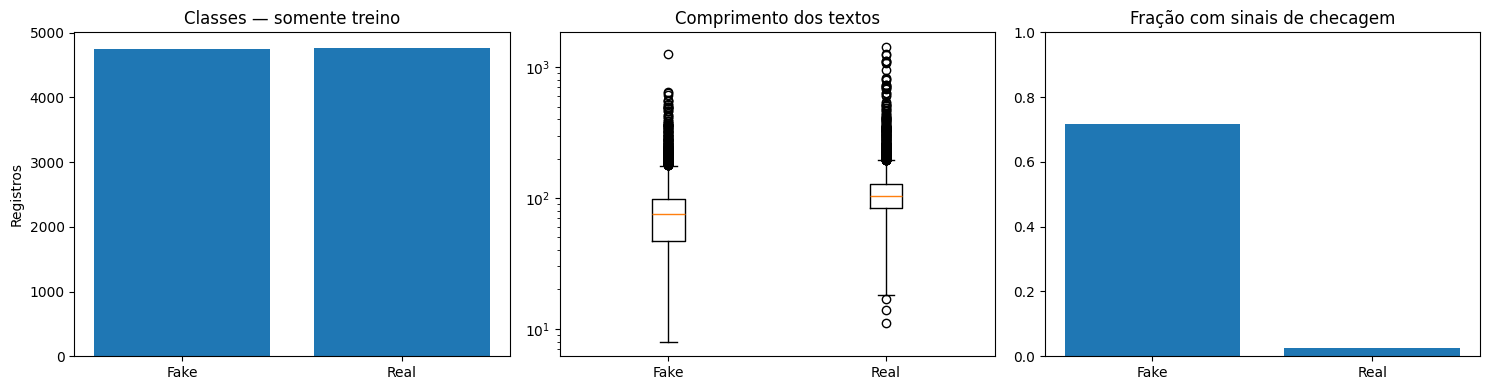

In [3]:
def salvar_grafico(fig, nome):
    fig.tight_layout()
    for extensao in ["png", "svg"]:
        fig.savefig(GRAPH_DIR / f"{nome}.{extensao}", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
contagens = y_train.value_counts().reindex([0, 1])
axes[0].bar(["Fake", "Real"], contagens)
axes[0].set_title("Classes — somente treino")
axes[0].set_ylabel("Registros")
axes[1].boxplot([auditoria.loc[auditoria.label.eq(k), "palavras"] for k in [0, 1]])
axes[1].set_xticks([1, 2], ["Fake", "Real"])
axes[1].set_yscale("log")
axes[1].set_title("Comprimento dos textos")
taxas = auditoria.assign(sinal=auditoria.pistas_residuais.ne("")).groupby("label").sinal.mean().reindex([0, 1])
axes[2].bar(["Fake", "Real"], taxas)
axes[2].set_ylim(0, 1)
axes[2].set_title("Fração com sinais de checagem")
salvar_grafico(fig, "01_auditoria_treino")


## 2. Validação cruzada e previsões fora da amostra — protocolo

Usa StratifiedKFold com cinco dobras, embaralhamento e seed 42. Cada registro é validado exatamente uma vez por modelo, por um pipeline que não recebeu esse registro no ajuste. TF-IDF e OneHotEncoder são ajustados novamente somente nos registros de treino de cada dobra.

As quatro avaliações usam as mesmas dobras externas. O stacking possui outras cinco dobras internas, usadas para treinar a regressão logística final com previsões fora da amostra das bases. Os ajustes finais em todo o desenvolvimento não geram as métricas OOF.

As dobras são estratificadas por registro: eventos, autores e fontes podem aparecer em mais de uma dobra. O holdout do 01 e os dados externos não participam destas avaliações.


In [4]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
divisoes_cv = list(cv.split(X_train, y_train))
atribuicao_dobras = np.full(len(X_train), -1, dtype=int)
visitas = np.zeros(len(X_train), dtype=int)
for dobra, (idx_fit, idx_val) in enumerate(divisoes_cv, start=1):
    if not set(idx_fit).isdisjoint(idx_val):
        raise ValueError("Sobreposição de índices entre treino e validação.")
    atribuicao_dobras[idx_val] = dobra
    visitas[idx_val] += 1
if not np.all(visitas == 1):
    raise ValueError("Cada registro deve aparecer uma única vez na validação externa ao stacking.")
mapa_dobras = train[["id_original", "label"]].copy()
mapa_dobras["dobra_validacao"] = atribuicao_dobras
mapa_dobras.to_csv(REPORT_DIR / "mapa_dobras_cv.csv", index=False)
display(pd.crosstab(mapa_dobras.dobra_validacao, mapa_dobras.label).rename(columns=LABEL_NAMES))
avaliacoes_modelos = {}
tempos_finais = {}


def base_texto_autor(classificador):
    return Pipeline([("features", make_features(max_features=20000)), ("clf", classificador)])


def avaliar_modelo(modelo, nome):
    predicoes = np.full(len(X_train), -1, dtype=int)
    escores = np.full(len(X_train), np.nan)
    dobras = np.full(len(X_train), -1, dtype=int)
    cobertura_oof = np.zeros(len(X_train), dtype=int)
    registros = []
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        for dobra, (idx_fit, idx_val) in enumerate(divisoes_cv, start=1):
            modelo_dobra = clone(modelo)
            inicio = perf_counter()
            modelo_dobra.fit(X_train.iloc[idx_fit], y_train.iloc[idx_fit])
            tempo_ajuste = perf_counter() - inicio
            inicio = perf_counter()
            previsto = modelo_dobra.predict(X_train.iloc[idx_val])
            # Margem ou probabilidade da classe Real; usadas somente como escores.
            if hasattr(modelo_dobra, "decision_function"):
                margem = modelo_dobra.decision_function(X_train.iloc[idx_val])
            else:
                indice_real = list(modelo_dobra.classes_).index(1)
                margem = modelo_dobra.predict_proba(X_train.iloc[idx_val])[:, indice_real]
            tempo_predicao = perf_counter() - inicio
            predicoes[idx_val] = previsto
            escores[idx_val] = margem
            dobras[idx_val] = dobra
            cobertura_oof[idx_val] += 1
            registros.append({"dobra": dobra, "n_treino": len(idx_fit), "n_validacao": len(idx_val),
                "f1_macro": float(f1_score(y_train.iloc[idx_val], previsto, average="macro", zero_division=0)),
                "accuracy": float(accuracy_score(y_train.iloc[idx_val], previsto)),
                "ajuste_segundos": tempo_ajuste, "predicao_e_escore_segundos": tempo_predicao})
            print(f"{nome} — dobra {dobra}/{N_SPLITS} concluída")
    if not np.all(cobertura_oof == 1):
        raise RuntimeError("Cobertura OOF inválida: cada registro deve receber exatamente uma previsão.")
    if not np.array_equal(dobras, atribuicao_dobras):
        raise RuntimeError("As dobras do modelo diferem do protocolo comum.")
    if (predicoes < 0).any() or not np.isfinite(escores).all():
        raise RuntimeError("Previsões fora da amostra incompletas.")
    resultados = pd.DataFrame(registros)
    relatorio = classification_report(y_train, predicoes, labels=[0, 1],
        target_names=["Fake", "Real"], output_dict=True, zero_division=0)
    if not isinstance(relatorio, dict):
        raise TypeError("Relatório deve ser um dicionário.")
    matriz = confusion_matrix(y_train, predicoes, labels=[0, 1])
    metricas = {"n": len(X_train), "f1_macro_oof": float(f1_score(y_train, predicoes, average="macro")),
        "accuracy_oof": float(accuracy_score(y_train, predicoes)),
        "cv_f1_macro": float(resultados["f1_macro"].mean()),
        "cv_std": float(resultados["f1_macro"].std(ddof=1)),
        "roc_auc_real_oof": float(roc_auc_score(y_train, escores)),
        "average_precision_fake_oof": float(average_precision_score(1 - y_train, -escores)),
        "classification_report": relatorio, "confusion_matrix": matriz.tolist()}
    pasta = REPORT_DIR / nome
    pasta.mkdir(parents=True, exist_ok=True)
    resultados.to_csv(pasta / "metricas_por_dobra.csv", index=False)
    audit = train.copy()
    audit["dobra"] = dobras
    audit["predito"] = predicoes
    audit["escore_real"] = escores
    audit["acerto"] = y_train.to_numpy() == predicoes
    audit.to_csv(pasta / "predicoes_oof.csv", index=False)
    audit.loc[~audit["acerto"]].to_csv(pasta / "erros_oof.csv", index=False)
    (pasta / "metricas_cv.json").write_text(json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8")
    display(pd.DataFrame(relatorio).T)
    display(resultados)
    return {"metricas": metricas, "resultados": resultados, "predicoes": predicoes,
            "escores": escores, "matriz": matriz, "dobras": dobras}


label,Fake,Real
dobra_validacao,,
1,950,954
2,951,953
3,951,953
4,950,953
5,950,953


## 3. Treinamento — Regressão logística

Classificador linear de referência, com regularização padrão. Aprende pesos para os atributos textuais e as categorias de autor. A célula avalia o pipeline nas dobras comuns e depois o ajusta em todo o treino do 01. O ajuste completo não é usado para calcular as métricas OOF.


In [5]:
modelo_regressao_logistica = base_texto_autor(LogisticRegression(max_iter=2000, random_state=SEED))
avaliacoes_modelos["regressao_logistica"] = avaliar_modelo(modelo_regressao_logistica, "regressao_logistica")
inicio = perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    modelo_regressao_logistica.fit(X_train, y_train)
tempos_finais["regressao_logistica"] = perf_counter() - inicio
print("Ajuste final em segundos:", tempos_finais["regressao_logistica"])


regressao_logistica — dobra 1/5 concluída
regressao_logistica — dobra 2/5 concluída
regressao_logistica — dobra 3/5 concluída
regressao_logistica — dobra 4/5 concluída
regressao_logistica — dobra 5/5 concluída


,precision,recall,f1-score,support
Fake,0.991755,0.961911,0.976605,4752.000000
Real,0.963129,0.992027,0.977364,4766.000000
accuracy,0.976991,0.976991,0.976991,0.976991
macro avg,0.977442,0.976969,0.976985,9518.000000
weighted avg,0.977421,0.976991,0.976985,9518.000000


,dobra,n_treino,n_validacao,f1_macro,accuracy,ajuste_segundos,predicao_e_escore_segundos
0,1,7614,1904,0.978985,0.978992,2.135716,0.550926
1,2,7614,1904,0.981616,0.981618,2.086426,0.489602
2,3,7614,1904,0.969524,0.969538,2.106113,0.562252
3,4,7615,1903,0.981077,0.981083,2.130304,0.478823
4,5,7615,1903,0.973717,0.973726,2.232479,0.505854


Ajuste final em segundos: 2.650390700000571


## 4. Treinamento — Random forest

Combina 200 árvores de decisão. Pode capturar relações não lineares, mas o custo e a adequação a atributos textuais esparsos precisam ser observados na comparação. A célula avalia o pipeline nas dobras comuns e depois o ajusta em todo o treino do 01. O ajuste completo não é usado para calcular as métricas OOF.


In [6]:
modelo_random_forest = base_texto_autor(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED))
avaliacoes_modelos["random_forest"] = avaliar_modelo(modelo_random_forest, "random_forest")
inicio = perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    modelo_random_forest.fit(X_train, y_train)
tempos_finais["random_forest"] = perf_counter() - inicio
print("Ajuste final em segundos:", tempos_finais["random_forest"])


random_forest — dobra 1/5 concluída
random_forest — dobra 2/5 concluída
random_forest — dobra 3/5 concluída
random_forest — dobra 4/5 concluída
random_forest — dobra 5/5 concluída


,precision,recall,f1-score,support
Fake,0.977938,0.970118,0.974012,4752.000000
Real,0.970441,0.978179,0.974295,4766.000000
accuracy,0.974154,0.974154,0.974154,0.974154
macro avg,0.974190,0.974148,0.974153,9518.000000
weighted avg,0.974184,0.974154,0.974154,9518.000000


,dobra,n_treino,n_validacao,f1_macro,accuracy,ajuste_segundos,predicao_e_escore_segundos
0,1,7614,1904,0.972685,0.972689,3.107643,0.574843
1,2,7614,1904,0.978464,0.978466,3.246188,0.602891
2,3,7614,1904,0.972689,0.972689,2.997041,0.580064
3,4,7615,1903,0.975302,0.975302,3.123903,0.574584
4,5,7615,1903,0.971624,0.971624,3.048959,0.591761


Ajuste final em segundos: 3.8740594999981113


## 5. Treinamento — SVC linear

Usa LinearSVC com kernel linear, sem kernel RBF. Produz margens de decisão; essas margens não são probabilidades calibradas. A célula avalia o pipeline nas dobras comuns e depois o ajusta em todo o treino do 01. O ajuste completo não é usado para calcular as métricas OOF.


In [7]:
modelo_svc = base_texto_autor(LinearSVC(dual=True, max_iter=10000, random_state=SEED))
avaliacoes_modelos["svc"] = avaliar_modelo(modelo_svc, "svc")
inicio = perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    modelo_svc.fit(X_train, y_train)
tempos_finais["svc"] = perf_counter() - inicio
print("Ajuste final em segundos:", tempos_finais["svc"])


svc — dobra 1/5 concluída
svc — dobra 2/5 concluída
svc — dobra 3/5 concluída
svc — dobra 4/5 concluída
svc — dobra 5/5 concluída


,precision,recall,f1-score,support
Fake,0.992982,0.982534,0.987730,4752.000000
Real,0.982766,0.993076,0.987894,4766.000000
accuracy,0.987813,0.987813,0.987813,0.987813
macro avg,0.987874,0.987805,0.987812,9518.000000
weighted avg,0.987866,0.987813,0.987812,9518.000000


,dobra,n_treino,n_validacao,f1_macro,accuracy,ajuste_segundos,predicao_e_escore_segundos
0,1,7614,1904,0.990021,0.990021,2.567005,0.555109
1,2,7614,1904,0.986344,0.986345,2.470931,0.582820
2,3,7614,1904,0.984243,0.984244,2.061078,0.526578
3,4,7615,1903,0.992643,0.992643,2.088957,0.533624
4,5,7615,1903,0.985811,0.985812,2.004572,0.484518


Ajuste final em segundos: 4.419559300004039


## 6. Treinamento — ensemble stacking

Reúne regressão logística, random forest e LinearSVC. A regressão logística final aprende a partir das previsões internas fora da amostra. As bases são clonadas e reajustadas dentro das dobras; não reutiliza suas previsões de ajuste completo. Cada base mantém seu próprio TF-IDF e encoder de autor. A avaliação externa ao stacking usa as mesmas divisões das bases isoladas.


In [8]:
bases = [
    ("regressao_logistica", clone(modelo_regressao_logistica)),
    ("random_forest", clone(modelo_random_forest)),
    ("svc", clone(modelo_svc)),
]
stacking = StackingClassifier(
    estimators=bases,
    final_estimator=LogisticRegression(max_iter=2000, random_state=SEED),
    cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED),
    stack_method="auto", passthrough=False, n_jobs=1,
)
# Sem TF-IDF compartilhado antes do stacking: cada base aprende dentro de suas dobras.
pipeline = Pipeline([("schema", InputSchemaValidator()), ("clf", stacking)])

avaliacoes_modelos["stacking"] = avaliar_modelo(pipeline, "stacking")
metricas = avaliacoes_modelos["stacking"]["metricas"]
resultados = avaliacoes_modelos["stacking"]["resultados"]
predicoes = avaliacoes_modelos["stacking"]["predicoes"]
escores = avaliacoes_modelos["stacking"]["escores"]
matriz = avaliacoes_modelos["stacking"]["matriz"]
inicio = perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    pipeline.fit(X_train, y_train)
tempo_final = perf_counter() - inicio
tempos_finais["stacking"] = tempo_final
print("Ajuste final do stacking em segundos:", tempo_final)


stacking — dobra 1/5 concluída
stacking — dobra 2/5 concluída
stacking — dobra 3/5 concluída
stacking — dobra 4/5 concluída
stacking — dobra 5/5 concluída


,precision,recall,f1-score,support
Fake,0.991971,0.988005,0.989984,4752.000000
Real,0.988088,0.992027,0.990053,4766.000000
accuracy,0.990019,0.990019,0.990019,0.990019
macro avg,0.990030,0.990016,0.990019,9518.000000
weighted avg,0.990027,0.990019,0.990019,9518.000000


,dobra,n_treino,n_validacao,f1_macro,accuracy,ajuste_segundos,predicao_e_escore_segundos
0,1,7614,1904,0.990546,0.990546,51.469968,2.693911
1,2,7614,1904,0.988971,0.988971,50.346840,1.614186
2,3,7614,1904,0.988445,0.988445,51.720766,3.085612
3,4,7615,1903,0.994220,0.994220,51.616640,1.554243
4,5,7615,1903,0.987914,0.987914,57.000549,3.494291


Ajuste final do stacking em segundos: 68.40812759999244


## 7. Resultados da validação cruzada e previsões fora da amostra

Consolida as avaliações já executadas nas células de cada algoritmo, sem repetir o treinamento. A tabela mostra F1-macro, acurácia e tempos por dobra. As previsões incluem ID original, classe verdadeira, dobra de validação, classe prevista e escore de Real.

Para logística, SVC e stacking, o escore é a margem de decisão. Para random forest, é a probabilidade estimada de Real, sem calibração externa validada. Não compare as magnitudes dos escores entre algoritmos. Cada linha corresponde a uma previsão fora da amostra do procedimento completo, inclusive do stacking.


,modelo,dobra,n_treino,n_validacao,f1_macro,accuracy,ajuste_segundos,predicao_e_escore_segundos
0,regressao_logistica,1,7614,1904,0.978985,0.978992,2.135716,0.550926
1,regressao_logistica,2,7614,1904,0.981616,0.981618,2.086426,0.489602
2,regressao_logistica,3,7614,1904,0.969524,0.969538,2.106113,0.562252
3,regressao_logistica,4,7615,1903,0.981077,0.981083,2.130304,0.478823
4,regressao_logistica,5,7615,1903,0.973717,0.973726,2.232479,0.505854
5,random_forest,1,7614,1904,0.972685,0.972689,3.107643,0.574843
6,random_forest,2,7614,1904,0.978464,0.978466,3.246188,0.602891
7,random_forest,3,7614,1904,0.972689,0.972689,2.997041,0.580064
8,random_forest,4,7615,1903,0.975302,0.975302,3.123903,0.574584
9,random_forest,5,7615,1903,0.971624,0.971624,3.048959,0.591761


,modelo,id_original,label,dobra_validacao,predito,escore_real,acerto
0,regressao_logistica,1,1,2,1,4.150435,True
1,regressao_logistica,2,1,3,1,2.512970,True
2,regressao_logistica,4,0,4,0,-4.060078,True
3,regressao_logistica,5,0,1,0,-5.380456,True
4,regressao_logistica,6,1,3,1,3.358816,True
9518,random_forest,1,1,2,1,0.900000,True
9519,random_forest,2,1,3,1,0.760000,True
9520,random_forest,4,0,4,0,0.190000,True
9521,random_forest,5,0,1,0,0.085000,True
9522,random_forest,6,1,3,1,0.900000,True


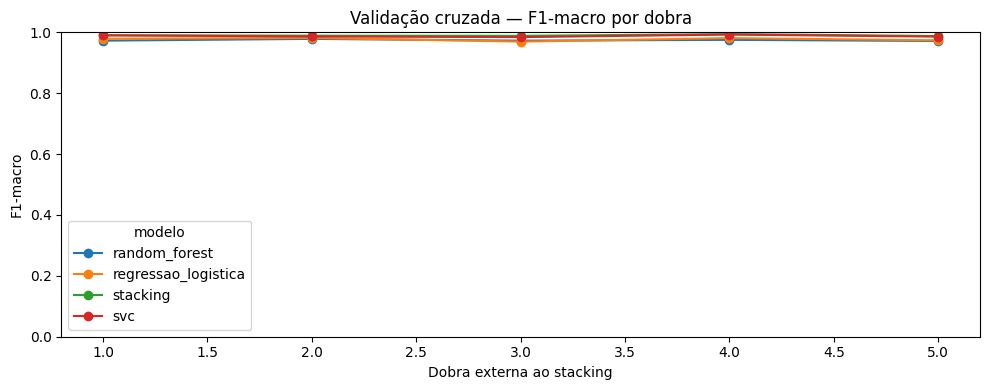

In [9]:
tabelas_cv = []
tabelas_oof = []
for nome, avaliacao in avaliacoes_modelos.items():
    tabela_cv = avaliacao["resultados"].copy()
    tabela_cv.insert(0, "modelo", nome)
    tabelas_cv.append(tabela_cv)
    tabela_oof = train[["id_original", "label"]].copy()
    tabela_oof.insert(0, "modelo", nome)
    tabela_oof["dobra_validacao"] = avaliacao["dobras"]
    tabela_oof["predito"] = avaliacao["predicoes"]
    tabela_oof["escore_real"] = avaliacao["escores"]
    tabela_oof["acerto"] = tabela_oof.label.to_numpy() == tabela_oof.predito.to_numpy()
    if tabela_oof.id_original.duplicated().any() or len(tabela_oof) != len(X_train):
        raise RuntimeError(f"Previsões OOF incompletas ou duplicadas: {nome}.")
    tabelas_oof.append(tabela_oof)
resultados_cv_modelos = pd.concat(tabelas_cv, ignore_index=True)
previsoes_oof_modelos = pd.concat(tabelas_oof, ignore_index=True)
resultados_cv_modelos.to_csv(REPORT_DIR / "validacao_cruzada_modelos.csv", index=False)
previsoes_oof_modelos.to_csv(REPORT_DIR / "previsoes_oof_modelos.csv", index=False)
display(resultados_cv_modelos)
display(previsoes_oof_modelos.groupby("modelo", sort=False).head(5))
fig, ax = plt.subplots(figsize=(10, 4))
resultados_cv_modelos.pivot(index="dobra", columns="modelo", values="f1_macro").plot(
    marker="o", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Validação cruzada — F1-macro por dobra")
ax.set_ylabel("F1-macro")
ax.set_xlabel("Dobra externa ao stacking")
salvar_grafico(fig, "05_validacao_cruzada_modelos")


## 8. Gráficos do stacking

Desempenho fora da amostra, estabilidade entre dobras e custo de ajuste.


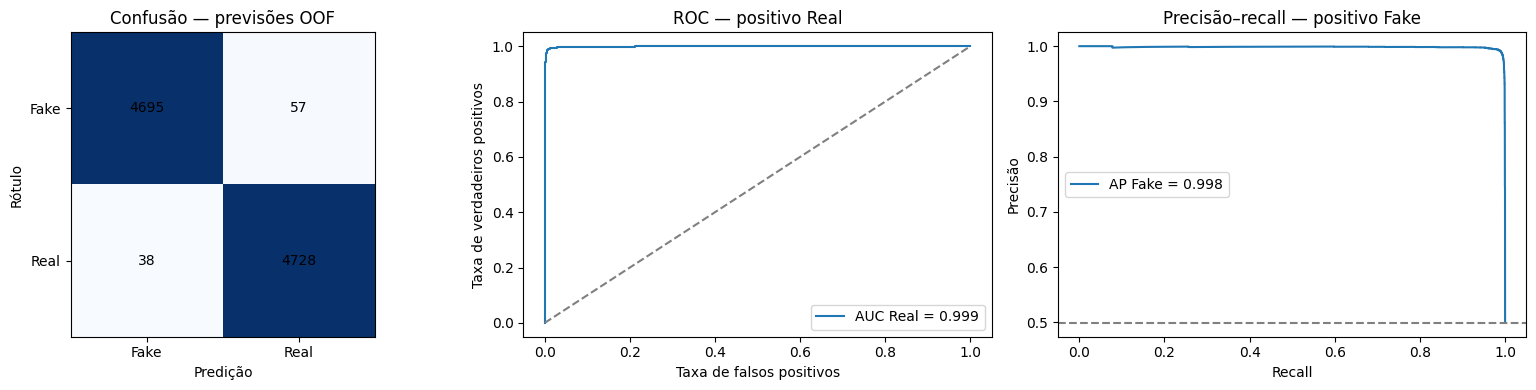

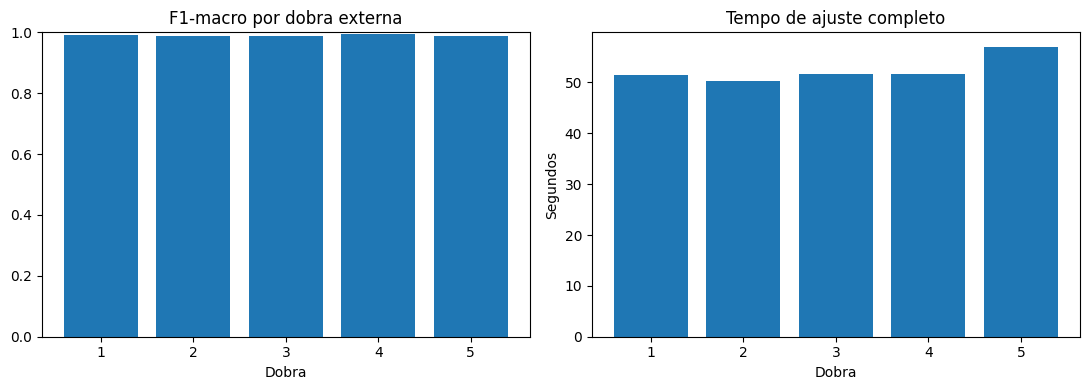

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(matriz, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(matriz[i, j]), ha="center", va="center")
axes[0].set_xticks([0, 1], ["Fake", "Real"])
axes[0].set_yticks([0, 1], ["Fake", "Real"])
axes[0].set_xlabel("Predição")
axes[0].set_ylabel("Rótulo")
axes[0].set_title("Confusão — previsões OOF")
fpr, tpr, _ = roc_curve(y_train, escores)
axes[1].plot(fpr, tpr, label=f"AUC Real = {metricas['roc_auc_real_oof']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("Taxa de falsos positivos")
axes[1].set_ylabel("Taxa de verdadeiros positivos")
axes[1].set_title("ROC — positivo Real")
axes[1].legend()
precisao, recall, _ = precision_recall_curve(1 - y_train, -escores)
axes[2].plot(recall, precisao, label=f"AP Fake = {metricas['average_precision_fake_oof']:.3f}")
axes[2].axhline(y_train.eq(0).mean(), linestyle="--", color="gray")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precisão")
axes[2].set_title("Precisão–recall — positivo Fake")
axes[2].legend()
salvar_grafico(fig, "02_desempenho_oof")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(resultados.dobra, resultados.f1_macro)
axes[0].set_ylim(0, 1)
axes[0].set_title("F1-macro por dobra externa")
axes[0].set_xlabel("Dobra")
axes[1].bar(resultados.dobra, resultados.ajuste_segundos)
axes[1].set_title("Tempo de ajuste completo")
axes[1].set_ylabel("Segundos")
axes[1].set_xlabel("Dobra")
salvar_grafico(fig, "03_estabilidade_e_custo")


## 9. Artefatos do stacking

Exporta o bundle congelado esperado pelo 03, contendo as bases, as features, o estimador final e o manifesto. Os resultados individuais ficam em subpastas identificadas pelo modelo.


In [11]:
features_ajustadas = []
stacking_ajustado = cast(StackingClassifier, pipeline.named_steps["clf"])
for nome, base in stacking_ajustado.named_estimators_.items():
    tfidf, onehot = fitted_base_features(base)
    features_ajustadas.append({"modelo": nome, "atributos_texto": len(tfidf.vocabulary_),
                              "categorias_autor": np.asarray(onehot.categories_[0]).size})
features_ajustadas = pd.DataFrame(features_ajustadas)
display(features_ajustadas)
features_ajustadas.to_csv(REPORT_DIR / "features_por_modelo.csv", index=False)
model_path = ROOT / MODEL_RELATIVE
model_path.parent.mkdir(parents=True, exist_ok=True)
bundle = {"schema_version": SCHEMA_VERSION, "model_type": "stacking",
    "pipeline": pipeline, "input_columns": FEATURE_COLUMNS.copy(), "label_names": LABEL_NAMES,
    "manifest": manifest, "best_params": {}, "params": pipeline.get_params(deep=True),
    "cv_f1_macro": metricas["cv_f1_macro"], "cv_std": metricas["cv_std"],
    "cv_protocol": "5 dobras externas e 5 internas; TF-IDF e autor one-hot dentro de cada base",
    "sklearn_version": sklearn.__version__}
joblib.dump(bundle, model_path)
# Confirma que o bundle serializado satisfaz o contrato compartilhado.
reloaded = load_bundle(model_path)
if not np.array_equal(reloaded["pipeline"].predict(X_train.iloc[:5]), pipeline.predict(X_train.iloc[:5])):
    raise RuntimeError("Predições divergentes após serialização.")
parametros = pipeline.get_params(deep=True)
(REPORT_DIR / "parametros.json").write_text(json.dumps(parametros, default=str,
    ensure_ascii=False, indent=2), encoding="utf-8")
execucao = {"python": platform.python_version(), "sklearn": sklearn.__version__,
    "pandas": pd.__version__, "numpy": np.__version__, "seed": SEED,
    "tempo_ajuste_final_segundos": tempo_final, "model_sha256": sha256_file(model_path),
    "manifest": manifest, "metricas": metricas}
(REPORT_DIR / "execucao.json").write_text(json.dumps(execucao, ensure_ascii=False, indent=2), encoding="utf-8")
print("Bundle stacking salvo:", model_path)
print("Relatórios e gráficos:", REPORT_DIR)


,modelo,atributos_texto,categorias_autor
0,regressao_logistica,20000,1272
1,random_forest,20000,1272
2,svc,20000,1272


Bundle stacking salvo: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\models\v2_stacking_texto_autor_exploratorio\stacking_bundle.joblib
Relatórios e gráficos: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\reports\v2_stacking_texto_autor_exploratorio


## 10. Diagnóstico e limitações

Resultados internos desta execução; holdout e dados externos permanecem reservados ao 03.


In [12]:
maioria = float(y_train.value_counts(normalize=True).max())
texto_diagnostico = f"""# Diagnóstico do ensemble stacking

- Registros de desenvolvimento: {len(train)}. Entrada: título + notícia + autor, conforme o 01.
- F1-macro fora da amostra: {metricas['f1_macro_oof']:.4f}.
- F1-macro médio das dobras: {metricas['cv_f1_macro']:.4f}; desvio entre dobras: {metricas['cv_std']:.4f}. Esse desvio não é intervalo de confiança.
- Acurácia OOF: {metricas['accuracy_oof']:.4f}. Referência descritiva da classe majoritária: {maioria:.4f} de acurácia.
- Fake classificados como Real: {matriz[0, 1]}; Real classificados como Fake: {matriz[1, 0]}.
- Ajuste final completo: {tempo_final:.2f} segundos. Ajustes das dobras: {resultados.ajuste_segundos.sum():.2f} segundos no total.
- Textos de treino com sinais residuais: {int(auditoria.pistas_residuais.ne('').sum())}. A lista é triagem e exige interpretação contextual.

## Interpretação

As métricas medem generalização interna por divisão aleatória estratificada. A comparação ao final usa as mesmas dobras para as bases e o ensemble. Diferenças internas são descritivas e não comprovam superioridade externa; o custo adicional do stacking deve ser considerado.

## Limitações e próximo passo

Duplicatas normalizadas foram bloqueadas, mas textos do mesmo evento, paráfrases, autores e marcas de fonte podem permanecer em dobras diferentes. Avaliação por grupos de evento/fonte e período depende de metadados e revisão adicional. A base não foi revisada integralmente: textos e autores podem conter pistas da checagem, inflando as métricas internas. O modelo aprende padrões textuais e não verifica fatos. Escores e probabilidades não têm calibração validada externamente.

O treinamento não leu o holdout nem dados externos. Execute o 03 com este bundle congelado. Confirme a independência da base externa por origem, notícia e evento: uma versão abstrativa das mesmas notícias não constitui, por si só, evidência OOD independente. Alterações após observar o teste exigem outro conjunto independente. Nenhuma métrica externa foi calculada neste notebook.
"""
display(Markdown(texto_diagnostico))
(REPORT_DIR / "diagnostico.md").write_text(texto_diagnostico, encoding="utf-8")


# Diagnóstico do ensemble stacking

- Registros de desenvolvimento: 9518. Entrada: título + notícia + autor, conforme o 01.
- F1-macro fora da amostra: 0.9900.
- F1-macro médio das dobras: 0.9900; desvio entre dobras: 0.0025. Esse desvio não é intervalo de confiança.
- Acurácia OOF: 0.9900. Referência descritiva da classe majoritária: 0.5007 de acurácia.
- Fake classificados como Real: 57; Real classificados como Fake: 38.
- Ajuste final completo: 68.41 segundos. Ajustes das dobras: 262.15 segundos no total.
- Textos de treino com sinais residuais: 3524. A lista é triagem e exige interpretação contextual.

## Interpretação

As métricas medem generalização interna por divisão aleatória estratificada. A comparação ao final usa as mesmas dobras para as bases e o ensemble. Diferenças internas são descritivas e não comprovam superioridade externa; o custo adicional do stacking deve ser considerado.

## Limitações e próximo passo

Duplicatas normalizadas foram bloqueadas, mas textos do mesmo evento, paráfrases, autores e marcas de fonte podem permanecer em dobras diferentes. Avaliação por grupos de evento/fonte e período depende de metadados e revisão adicional. A base não foi revisada integralmente: textos e autores podem conter pistas da checagem, inflando as métricas internas. O modelo aprende padrões textuais e não verifica fatos. Escores e probabilidades não têm calibração validada externamente.

O treinamento não leu o holdout nem dados externos. Execute o 03 com este bundle congelado. Confirme a independência da base externa por origem, notícia e evento: uma versão abstrativa das mesmas notícias não constitui, por si só, evidência OOD independente. Alterações após observar o teste exigem outro conjunto independente. Nenhuma métrica externa foi calculada neste notebook.


1801

## 11. Comparação final dos modelos

Compare F1-macro, erros por classe e tempos medidos nesta execução. Os quatro modelos usam as mesmas divisões e features. O desvio entre dobras não é intervalo de confiança. A tabela não substitui validação externa e não troca automaticamente o stacking utilizado no 03.


,modelo,f1_macro_oof,f1_macro_cv_media,f1_macro_cv_desvio,accuracy_oof,fake_como_real,real_como_fake,ajuste_cv_segundos,predicao_e_escore_cv_segundos,ajuste_final_segundos
3,stacking,0.990019,0.990019,0.002546,0.990019,57,38,262.154763,12.442244,68.408128
2,svc,0.987812,0.987812,0.003432,0.987813,83,33,11.192542,2.682648,4.419559
0,regressao_logistica,0.976985,0.976984,0.005209,0.976991,181,38,10.691038,2.587457,2.650391
1,random_forest,0.974153,0.974153,0.002766,0.974154,142,104,15.523735,2.924142,3.874059


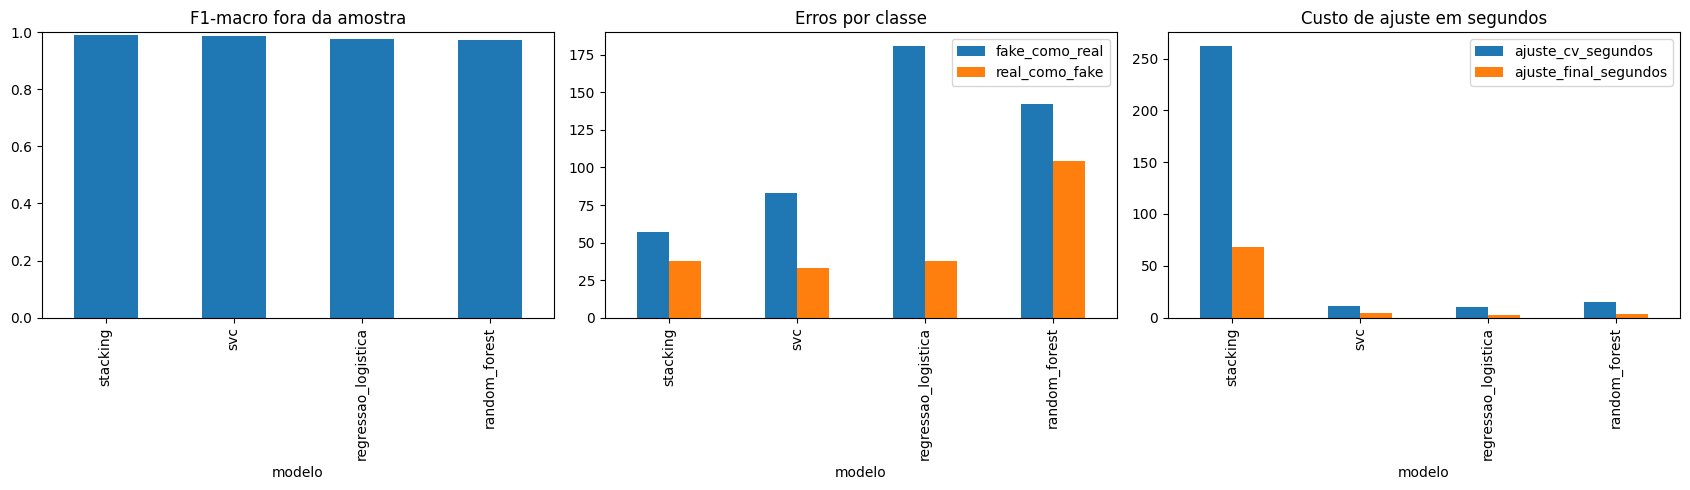

## Interpretação da comparação

F1-macro OOF do stacking: 0.9900. Maior F1-macro entre as bases isoladas: 0.9878.
Diferença descritiva stacking − melhor base: +0.0022.

Considere também os dois tipos de erro e os tempos da tabela. As dobras podem compartilhar fontes/eventos, e a base não foi revisada integralmente. Os resultados não demonstram generalização externa. O stacking permanece como artefato do experimento; nenhuma escolha é feita usando o holdout.


462

In [13]:
comparacao = []
for nome, avaliacao in avaliacoes_modelos.items():
    medidas = avaliacao["metricas"]
    tempos = avaliacao["resultados"]
    erros = avaliacao["matriz"]
    comparacao.append({"modelo": nome, "f1_macro_oof": medidas["f1_macro_oof"],
        "f1_macro_cv_media": medidas["cv_f1_macro"], "f1_macro_cv_desvio": medidas["cv_std"],
        "accuracy_oof": medidas["accuracy_oof"], "fake_como_real": int(erros[0, 1]),
        "real_como_fake": int(erros[1, 0]),
        "ajuste_cv_segundos": float(tempos["ajuste_segundos"].sum()),
        "predicao_e_escore_cv_segundos": float(tempos["predicao_e_escore_segundos"].sum()),
        "ajuste_final_segundos": tempos_finais[nome]})
comparacao = pd.DataFrame(comparacao).sort_values("f1_macro_oof", ascending=False)
display(comparacao)
comparacao.to_csv(REPORT_DIR / "comparacao_modelos.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
comparacao.plot.bar(x="modelo", y="f1_macro_oof", ax=axes[0], legend=False)
axes[0].set_ylim(0, 1)
axes[0].set_title("F1-macro fora da amostra")
comparacao.set_index("modelo")[["fake_como_real", "real_como_fake"]].plot.bar(ax=axes[1])
axes[1].set_title("Erros por classe")
comparacao.set_index("modelo")[["ajuste_cv_segundos", "ajuste_final_segundos"]].plot.bar(ax=axes[2])
axes[2].set_title("Custo de ajuste em segundos")
salvar_grafico(fig, "04_comparacao_modelos")
f1_bases = float(comparacao.loc[comparacao.modelo.ne("stacking"), "f1_macro_oof"].max())
f1_stacking = float(comparacao.loc[comparacao.modelo.eq("stacking"), "f1_macro_oof"].iloc[0])
interpretacao = f"""## Interpretação da comparação

F1-macro OOF do stacking: {f1_stacking:.4f}. Maior F1-macro entre as bases isoladas: {f1_bases:.4f}.
Diferença descritiva stacking − melhor base: {f1_stacking - f1_bases:+.4f}.

Considere também os dois tipos de erro e os tempos da tabela. As dobras podem compartilhar fontes/eventos, e a base não foi revisada integralmente. Os resultados não demonstram generalização externa. O stacking permanece como artefato do experimento; nenhuma escolha é feita usando o holdout.
"""
display(Markdown(interpretacao))
(REPORT_DIR / "comparacao_interpretacao.md").write_text(interpretacao, encoding="utf-8")
